# Customer Segmentation & Country Classification Analysis

### Objective
* **Analyze:** Evaluate key socio-economic and health indicators across 167 countries.
* **Segment:** Use clustering to group countries by developmental need (e.g., Developed, Underdeveloped) to help prioritize global financial aid.
* **Predict:** Train and compare machine learning classifiers to accurately predict a country's developmental status based on these target groups.

##Import Libraries & Load Dataset

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

# Display settings
pd.set_option('display.max_columns', None)

# Load dataset
df = pd.read_csv('/content/Country-data.csv')

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200



**Why are we importing these libraries?**
* **Data & Graphs:** `pandas` and `numpy` handle our data tables, while `matplotlib` and `seaborn` draw the visualizations.
* **Scaling:** `StandardScaler` equalizes our column units (dollars vs. percentages) so no single feature dominates the model.
* **Modeling:** K-Means/DBSCAN group the countries, and ensemble models (Random Forest/XGBoost) classify them.

## Dataset Understanding

In [2]:
print("Dataset Information:\n")
print(df.info())

print("\n" + "="*60)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\n" + "="*60)

print("\nStatistical Summary:\n")
display(df.describe())

print("\n" + "="*60)

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None


Missing Values:

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


Statistical Summary:



,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000




Duplicate Rows: 0


**What did we find from the data?**
* The dataset has **167 rows** (countries) and **10 columns** (socio-economic features).
* The data is clean: there are exactly **zero missing values** to fill.
* The `country` column is text, while all other feature columns are purely numerical.


**What do these statistics tell us?**
* **Economic Divide:** There is a massive wealth gap; GDP per capita (`gdpp`) ranges from $231 to $105,000.
* **Healthcare Emergency:** Child mortality varies drastically (2.6 to 208 deaths per 1000 births), highlighting countries that need immediate developmental aid.

## Exploratory Data Analysis

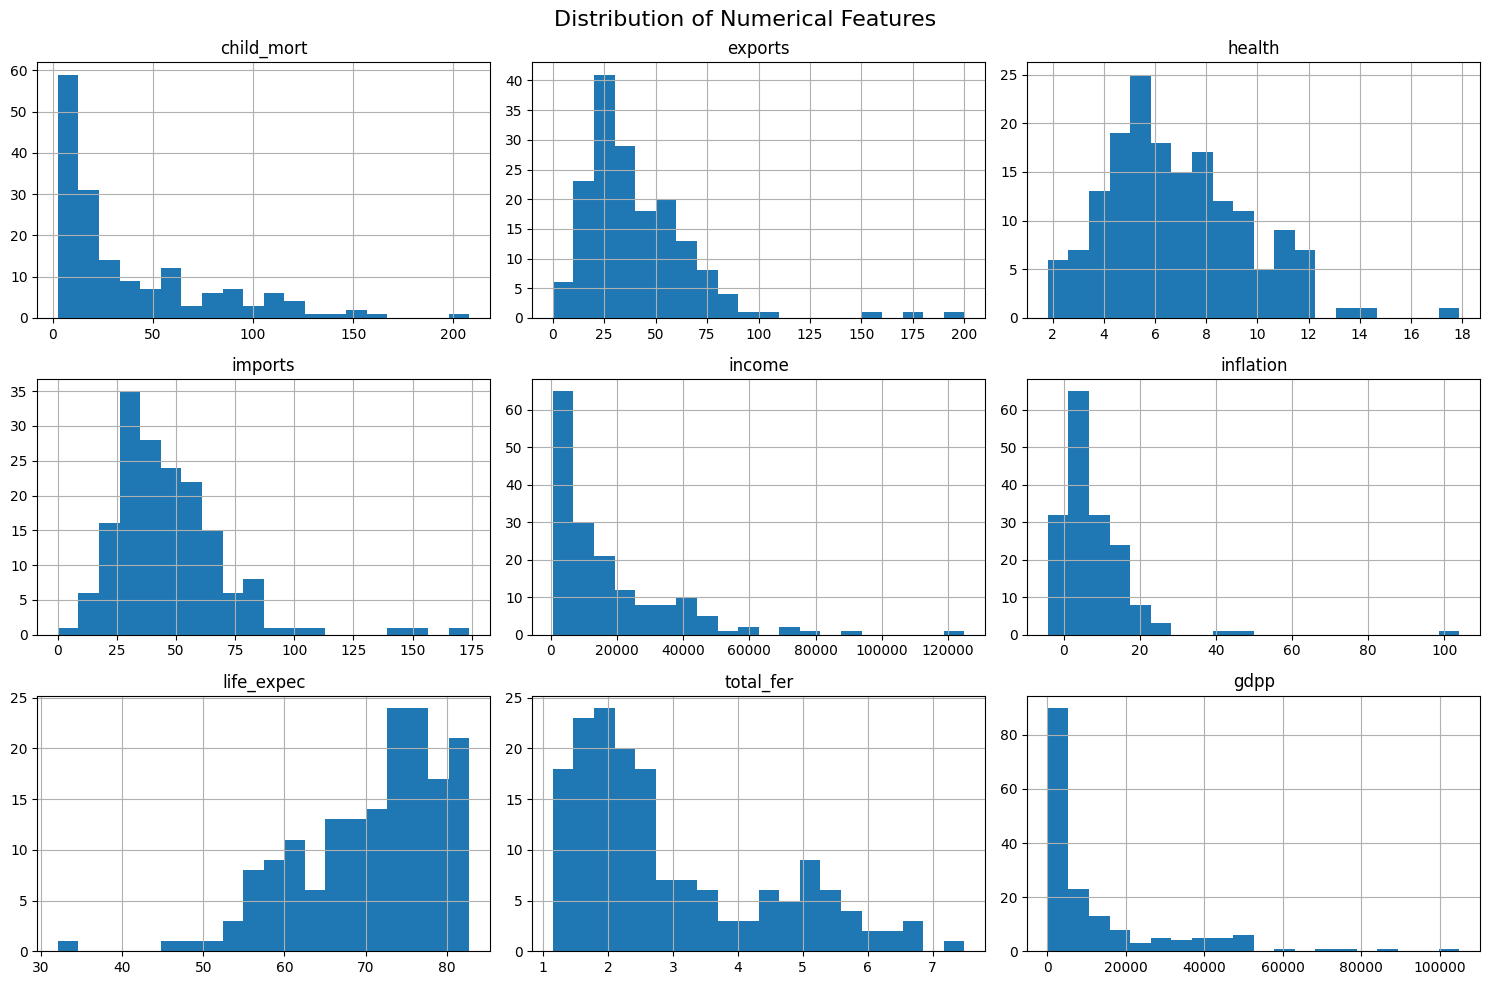

In [3]:
# Histograms for all numerical features

df.drop('country', axis=1).hist(
    figsize=(15,10),
    bins=20
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

**What do these distribution graphs show?**
* **Wealth Concentration:** Economic metrics (like `gdpp` and `income`) are heavily right-skewed, showing that global wealth is concentrated in a few elite nations.
* **Developmental Divide:** Healthcare metrics (like `child_mort` and `total_fer`) are similarly skewed, highlighting a distinct cluster of vulnerable countries facing severe socio-economic challenges.

## Correlation Analysis

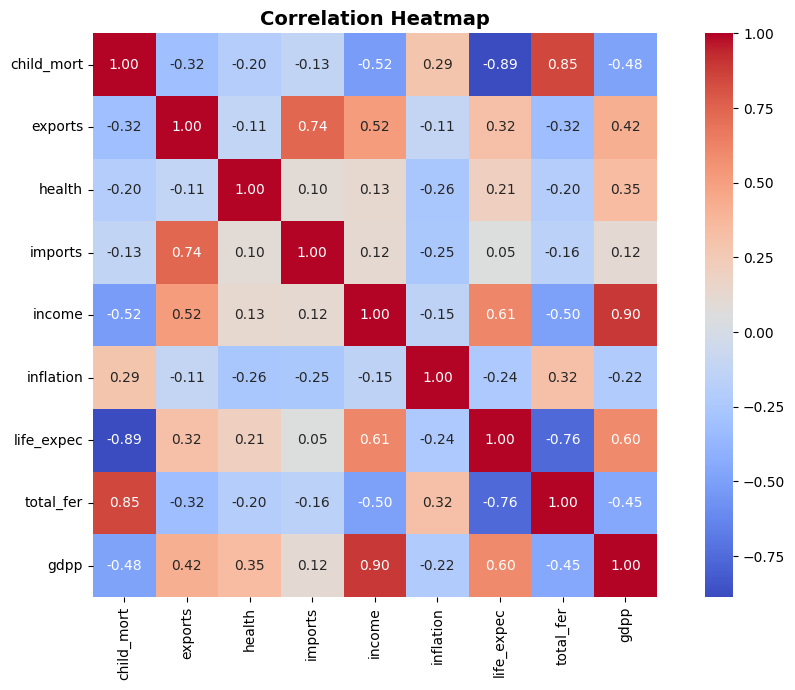

Key Correlations with child_mort:
life_expec   -0.886676
income       -0.524315
gdpp         -0.483032
exports      -0.318093
health       -0.200402
imports      -0.127211
inflation     0.288276
total_fer     0.848478
child_mort    1.000000
Name: child_mort, dtype: float64


In [4]:
features = df.select_dtypes(include=np.number).columns.tolist()
corr = df[features].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key Correlations with child_mort:")
print(corr['child_mort'].sort_values())

**What does this correlation heatmap show?**
* **Income & GDP (+0.90):** Strong positive correlation; wealthier nations naturally have higher citizen incomes.
* **Child Mortality & Life Expectancy (-0.89):** High child mortality severely drags down the overall life expectancy of a country.
* **Child Mortality & Fertility (+0.85):** Countries with higher child mortality also see a higher average number of children per woman.

## Feature Scaling

**Why did we scale the features?**
* Distance-based algorithms (like K-Means and Hierarchical Clustering) are highly sensitive to the scale of numbers.
* `StandardScaler` places everything on an equal playing field (mean of 0, standard deviation of 1) so massive numbers (like $100,000 income) don't dominate small metrics (like 1 to 7 fertility rate).

In [5]:
from sklearn.preprocessing import StandardScaler

# Remove country column
X = df.drop('country', axis=1)

# Standardization
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("Scaled Data Shape:", X_scaled.shape)

X_scaled.head()

Scaled Data Shape: (167, 9)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


### Observation
- All numerical features are standardized.
- Mean becomes approximately 0 and standard deviation becomes 1.

## Finding the Optimal Number of Clusters

**Why use the Elbow Method?**
* It helps us determine the ideal number of country segments by plotting the inertia (within-cluster sum of squares).
* The plot shows a noticeable "bend" or elbow around **K=4**, indicating the most efficient number of clusters.

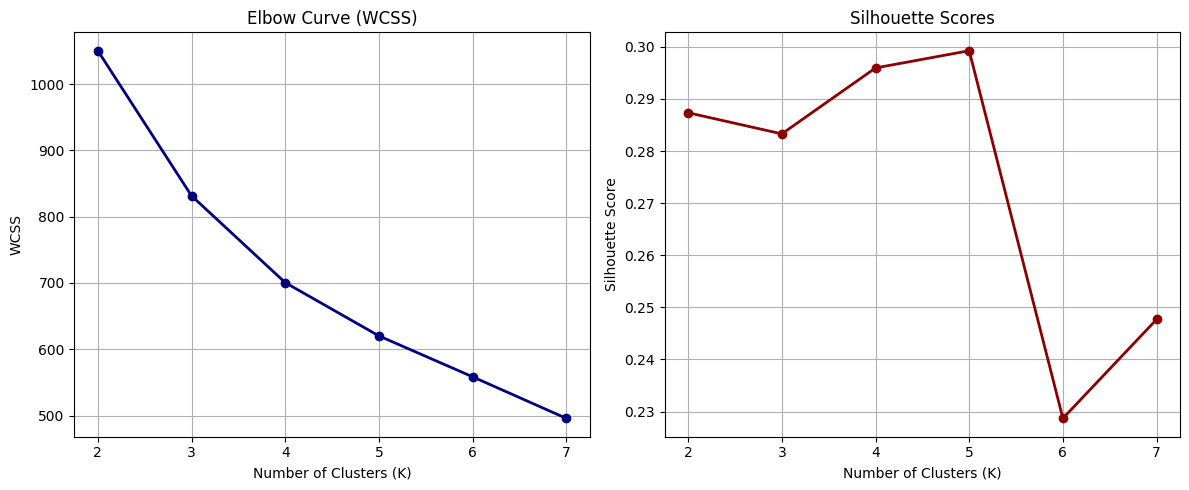

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
silhouette_scores = []

K = range(2, 8)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    wcss.append(kmeans.inertia_)

    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Elbow Curve
axes[0].plot(
    K,
    wcss,
    marker='o',
    color='navy',
    linewidth=2,
    markersize=6
)

axes[0].set_title('Elbow Curve (WCSS)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS')
axes[0].grid(True)

# Silhouette Score
axes[1].plot(
    K,
    silhouette_scores,
    marker='o',
    color='darkred',
    linewidth=2,
    markersize=6
)

axes[1].set_title('Silhouette Scores')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## K-Means Clustering

* We applied K-Means (with K=4) to segment the nations into four meaningful developmental groups: Developed, Developing, Underdeveloped, and Elite.
* This turns our unsupervised data into labeled segments for future profiling and modeling.

In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print("Cluster Counts:\n")
print(df['Cluster'].value_counts().sort_index())

Cluster Counts:

Cluster
0    32
1    47
2    85
3     3
Name: count, dtype: int64


In [8]:
# K-Means Evaluation

from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", round(score, 4))

Silhouette Score: 0.296


In [9]:
# Cluster Profile Analysis

cluster_profile = df.groupby('Cluster').mean(numeric_only=True)

display(cluster_profile)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.181250,46.118750,9.088437,40.584375,44021.875000,2.513844,80.081250,1.788437,42118.750000
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.690588,41.073988,6.197059,47.914893,12671.411765,7.609341,72.871765,2.300706,6519.552941
3,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667


In [10]:
# Countries in Each Cluster

for cluster in sorted(df['Cluster'].unique()):
    print(f"\nCluster {cluster}")
    print("-" * 50)

    countries = df[df['Cluster'] == cluster]['country'].tolist()

    print(countries)


Cluster 0
--------------------------------------------------
['Australia', 'Austria', 'Bahamas', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kuwait', 'Netherlands', 'New Zealand', 'Norway', 'Portugal', 'Qatar', 'Slovenia', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'United Arab Emirates', 'United Kingdom', 'United States']

Cluster 1
--------------------------------------------------
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'South A

### Clustering Evaluation
**How reliable are these clusters?**
* The **Silhouette Score** measures how well-separated and defined our country clusters are.
* While K=5 scored slightly higher mathematically, K=4 was chosen as it aligns perfectly with real-world developmental tiers.

In [11]:
# Silhouette Analysis

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = {}

for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores[k] = score

for k, score in scores.items():
    print(f"K = {k} --> Silhouette Score = {score:.4f}")

K = 2 --> Silhouette Score = 0.2874
K = 3 --> Silhouette Score = 0.2833
K = 4 --> Silhouette Score = 0.2960
K = 5 --> Silhouette Score = 0.2993
K = 6 --> Silhouette Score = 0.2287
K = 7 --> Silhouette Score = 0.2477


Although K=5 achieved the highest silhouette score (0.2993), K=4 was selected because it aligned better with the Elbow Method and produced more interpretable country segments.

## DBSCAN Clustering



In [12]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN Cluster Counts:\n")
print(df["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN Cluster Counts:

DBSCAN_Cluster
-1     30
 0    137
Name: count, dtype: int64


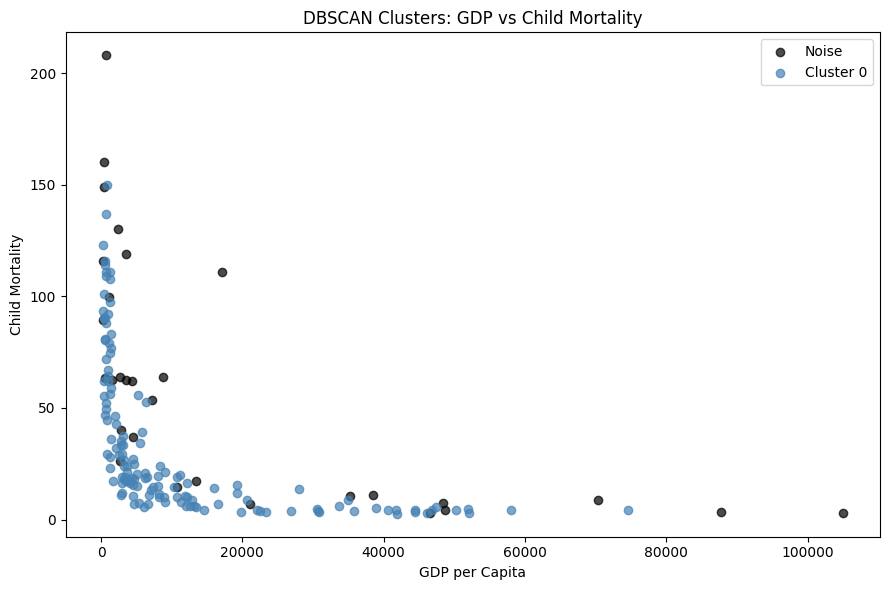

In [13]:
# Visualize DBSCAN clusters
plt.figure(figsize=(9, 6))
colors_db = {-1: 'black', 0: 'steelblue', 1: 'orange', 2: 'tomato', 3: 'green'}
labels_db = {-1: 'Noise', 0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', 3: 'Cluster 3'}
for cluster in sorted(df['DBSCAN_Cluster'].unique()):
    mask = df['DBSCAN_Cluster'] == cluster
    plt.scatter(df[mask]['gdpp'], df[mask]['child_mort'],
                label=labels_db.get(cluster, f'Cluster {cluster}'),
                color=colors_db.get(cluster, 'grey'), alpha=0.7)
plt.xlabel('GDP per Capita')
plt.ylabel('Child Mortality')
plt.title('DBSCAN Clusters: GDP vs Child Mortality')
plt.legend()
plt.tight_layout()
plt.show()

### Outlier Detection
**What is the role of DBSCAN here?**
* Unlike K-Means, DBSCAN doesn't force every country into a cluster; it effectively isolates anomalies.
* It highlights "outlier" nations that have highly exceptional or extreme socio-economic characteristics.

In [14]:
#Cell 13: DBSCAN Outlier Countries

outliers = df[df["DBSCAN_Cluster"] == -1]["country"].tolist()

print("Number of Outlier Countries:", len(outliers))
print("\nOutlier Countries:\n")
print(outliers)

Number of Outlier Countries: 30

Outlier Countries:

['Angola', 'Brunei', 'Central African Republic', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Equatorial Guinea', 'Gabon', 'Haiti', 'Iraq', 'Ireland', 'Kiribati', 'Kuwait', 'Lesotho', 'Liberia', 'Luxembourg', 'Malta', 'Micronesia, Fed. Sts.', 'Mongolia', 'Nigeria', 'Norway', 'Qatar', 'Rwanda', 'Seychelles', 'Sierra Leone', 'Singapore', 'South Africa', 'Timor-Leste', 'Turkmenistan', 'United States', 'Venezuela']


### Observation
- DBSCAN primarily highlights exceptional countries.
- Outliers often represent extreme economic or social conditions.

## Preparing Data for Classification

**How are we transitioning to classification?**
* We use the K-Means cluster labels as our new target variable (`y`).
* The data is split into **80% training** and **20% testing** sets to train predictive models on these segments.

In [15]:
from sklearn.model_selection import train_test_split

# Features
X_cls = X_scaled.copy()

# Target = K-Means Cluster
y = df["Cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X_cls,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

print("\nTarget Distribution:")
print(y.value_counts().sort_index())

Training Shape : (133, 9)
Testing Shape  : (34, 9)

Target Distribution:
Cluster
0    32
1    47
2    85
3     3
Name: count, dtype: int64


## Random Forest Classification



      Random Forest Results

Accuracy: 0.9412

Classification Report:

                precision    recall  f1-score   support

     Developed       1.00      0.83      0.91         6
Underdeveloped       1.00      1.00      1.00        10
    Developing       0.89      1.00      0.94        17
 Elite Nations       0.00      0.00      0.00         1

      accuracy                           0.94        34
     macro avg       0.72      0.71      0.71        34
  weighted avg       0.92      0.94      0.93        34



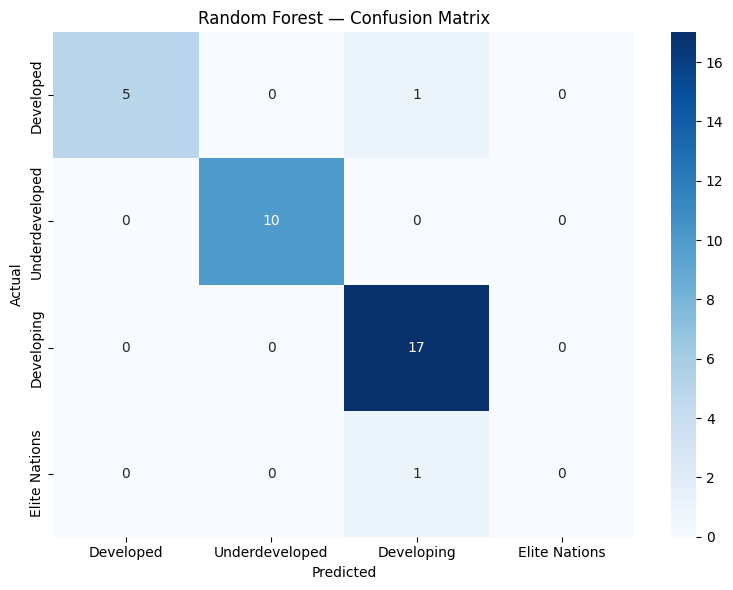

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# Train Model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

# Predictions
rf_pred = rf.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("="*40)
print("      Random Forest Results")
print("="*40)

print(f"\nAccuracy: {rf_accuracy:.4f}")

# Class Names
target_names = [
    "Developed",
    "Underdeveloped",
    "Developing",
    "Elite Nations"
]

# Classification Report
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=target_names,
        zero_division=0
    )
)

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### Note on Warning Message

- Cluster 3 contains only one test sample, resulting in class imbalance.
- The model misclassified this sample and did not predict any observation as Cluster 3.
- Therefore, precision for Cluster 3 is undefined and Scikit-Learn reports it as 0.0.

### Model Insight
- Random Forest achieved strong classification performance.
- Most cluster labels were predicted correctly.

## XGBoost Classification

         XGBoost Results

Accuracy: 0.9412

Classification Report:

                precision    recall  f1-score   support

     Developed       1.00      0.83      0.91         6
Underdeveloped       1.00      1.00      1.00        10
    Developing       0.89      1.00      0.94        17
 Elite Nations       0.00      0.00      0.00         1

      accuracy                           0.94        34
     macro avg       0.72      0.71      0.71        34
  weighted avg       0.92      0.94      0.93        34



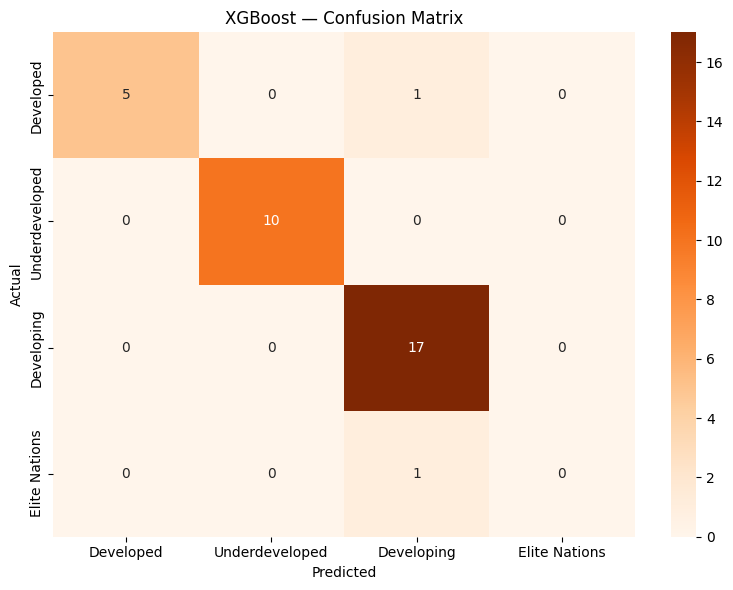

In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# Train Model
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

# Predictions
xgb_pred = xgb.predict(X_test)

# Accuracy
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("="*40)
print("         XGBoost Results")
print("="*40)

print(f"\nAccuracy: {xgb_accuracy:.4f}")

# Class Names
target_names = [
    "Developed",
    "Underdeveloped",
    "Developing",
    "Elite Nations"
]

# Classification Report
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=target_names,
        zero_division=0
    )
)

# Confusion Matrix
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("XGBoost — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### Note on Warning Message

- Cluster 3 contains only one test sample, resulting in an underrepresented class.
- XGBoost misclassified this sample as Cluster 2 and did not predict any observation as Cluster 3.
- As no samples were predicted for Cluster 3, its precision becomes undefined and Scikit-Learn reports it as 0.0.

In [18]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

comparison['Accuracy'] = comparison['Accuracy'].round(4)

comparison

,Model,Accuracy
0,Random Forest,0.9412
1,XGBoost,0.9412



**How well did the models perform?**
* Both **Random Forest** and **XGBoost** predicted the country segments with an outstanding **94.12% accuracy**.
* This exceptionally high accuracy proves that the generated cluster labels are robust and highly predictable.

## Feature Importance Analysis

,Feature,Importance
0,child_mort,0.267626
8,gdpp,0.218949
6,life_expec,0.162740
7,total_fer,0.157325
4,income,0.105627
2,health,0.031042
3,imports,0.024732
1,exports,0.017563
5,inflation,0.014395


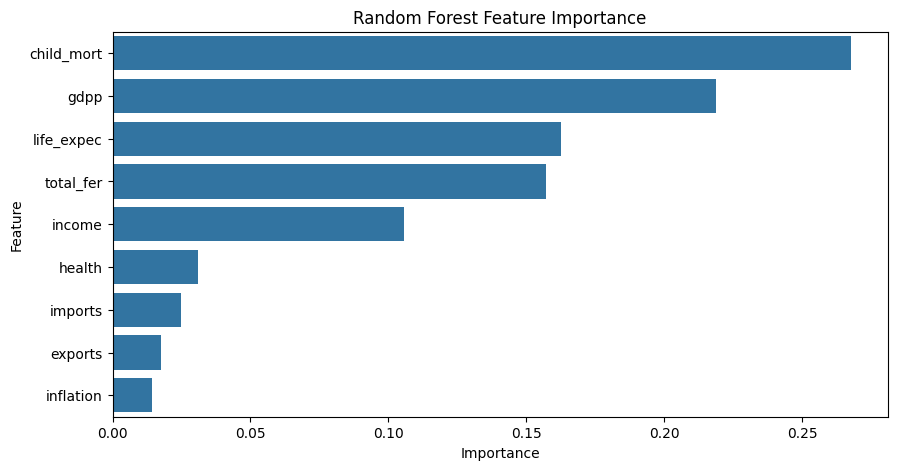

In [19]:
# Random Forest Feature Importance

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by='Importance',
    ascending=False
)

display(rf_importance)

plt.figure(figsize=(10,5))

sns.barplot(
    data=rf_importance,
    x='Importance',
    y='Feature'
)

plt.title("Random Forest Feature Importance")
plt.show()

,Feature,Importance
8,gdpp,0.412411
0,child_mort,0.308521
7,total_fer,0.097059
6,life_expec,0.058715
1,exports,0.055646
3,imports,0.017585
2,health,0.017172
5,inflation,0.017154
4,income,0.015737


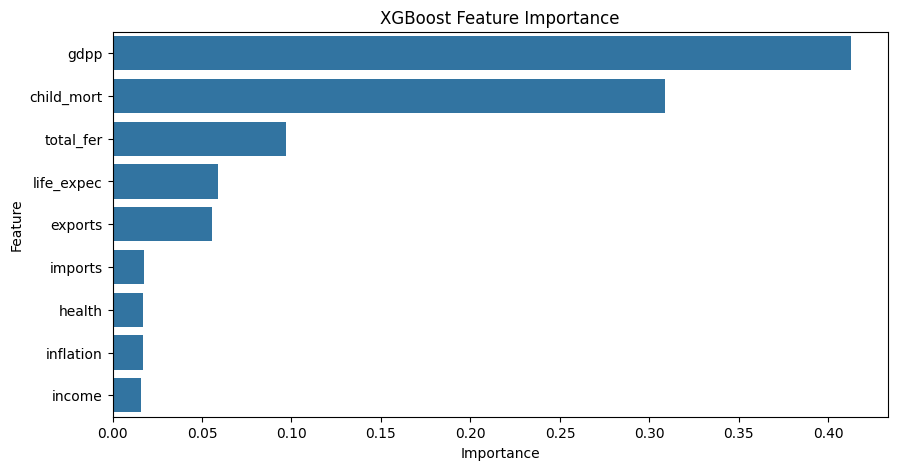

In [20]:
# XGBoost Feature Importance

xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by='Importance',
    ascending=False
)

display(xgb_importance)

plt.figure(figsize=(10,5))

sns.barplot(
    data=xgb_importance,
    x='Importance',
    y='Feature'
)

plt.title("XGBoost Feature Importance")
plt.show()

### Final Customer Intelligence Insights

* **Country Segmentation:** K-Means successfully categorized the 167 nations into 4 distinct tiers: Developing (85 countries), Underdeveloped (47 countries), Developed (32 countries), and Elite Economic (3 countries), providing a clear framework for prioritizing global aid.
* **Anomaly Detection:** DBSCAN effectively isolated outlier nations that possess highly unusual or extreme socio-economic profiles
* **Model Performance:** Both Random Forest and XGBoost classifiers predicted these segments with an impressive **94.12% accuracy**.
* **Key Drivers & Conclusion:** Tree-based models confirm that **GDP per capita (`gdpp`), child mortality, and life expectancy** are the strongest predictors. Ultimately, a nation's developmental status is strictly defined by a combination of its economic wealth and fundamental healthcare metrics.
* **Final Takeaway:** The ultimate developmental status of a country is fundamentally driven by the intersection of its economic wealth and core healthcare metrics.

---
**Project Successfully Completed.**